In [1]:
import os
import sys
import time
import calendar
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.cm import coolwarm
from datetime import datetime, timedelta
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

cell_constants = {
    'H' : 24*60,
    'C_max' : 0.5, # 1/h
    'tilde_Q_1' : 2.5, # Ah
    'tilde_V' : 3.3, # V
    'N' : 0.5, # divided by 1e6
    'cons_z': 0.60,
    'cons_alpha': 28.966,
    'cons_beta': 74.112,
    'cons_delta': 1/60,
    'cons_eta': 152.5,
    'cons_E_a': 31500,
    'cons_R_g': 8.314,
    'cons_T': 273.15 + 25, # K
    'cons_omega': np.exp(-31500 / (8.314 * (273.15 + 25)))}

def aging(tilde_b_t, tilde_q_t, tilde_Q_t, ah_t, Sigma_rho_t, cell_constants, approx=False):
    mu_t = cell_constants['cons_beta'] * cell_constants['cons_omega'] * cell_constants['cons_z'] * np.power(ah_t, cell_constants['cons_z'] - 1)
    nu_t = 0 if tilde_Q_t == 0 else cell_constants['cons_alpha'] / (cell_constants['cons_beta'] * tilde_Q_t)
    lambda_t = 0 if tilde_Q_t == 0 else cell_constants['cons_eta'] / (cell_constants['cons_R_g'] * cell_constants['cons_T'] * tilde_Q_t)
    if approx == False:
        rho_t = mu_t * abs(tilde_b_t) * (1 + (nu_t * tilde_q_t)) * np.exp(lambda_t * abs(tilde_b_t))
    else:
        rho_t = mu_t * abs(tilde_b_t) * (1 + (nu_t * (tilde_Q_t/2)))
    Sigma_rho_t = Sigma_rho_t + rho_t
    l_t = Sigma_rho_t * cell_constants['cons_delta']
    tilde_Q_t = cell_constants['tilde_Q_1'] * (1 - l_t)
    return l_t, tilde_Q_t, mu_t, nu_t, Sigma_rho_t

def bang_bang_simulator(cell_constants, approx=False):
    E = int(20 * 365 * cell_constants['H'] + 6 * cell_constants['H'])
    # Pre-allocate cell-level variables
    tilde_b = np.zeros((E,))
    tilde_q = np.zeros((E,))
    tilde_Q = np.zeros((E,))
    l = np.zeros((E,))
    ah = np.zeros((E,))
    mu_one_plus_nu_q = np.zeros((E,))
    Sigma_rho = np.zeros((E,))
    # Initilize variables
    cycle_state = 'charge'
    tilde_b_t = 0.0
    tilde_q_t = 0.0
    tilde_q_t_1 = 0.0
    tilde_Q_t = cell_constants['tilde_Q_1']
    Sigma_rho_t = 0.0
    ah_t = 2.5
    for e in range(E):
        if tilde_Q_t <= 0.90 * cell_constants['tilde_Q_1']:
            break
        tilde_b_t = -cell_constants['C_max'] * tilde_Q_t if cycle_state == 'charge' else cell_constants['C_max'] * tilde_Q_t
        tilde_q_t_1 = tilde_q_t
        tilde_q_t = np.clip(tilde_q_t_1 - tilde_b_t * cell_constants['cons_delta'], 0, tilde_Q_t)
        tilde_b_t = (tilde_q_t - tilde_q_t_1) / cell_constants['cons_delta']
        ah_t = ah_t + (abs(tilde_b_t)*cell_constants['cons_delta'])
        l_t, tilde_Q_t, mu_t, nu_t, Sigma_rho_t = aging(tilde_b_t, tilde_q_t, tilde_Q_t, ah_t, Sigma_rho_t, cell_constants, approx)
        mu_one_plus_nu_q_t = mu_t * (1 + (nu_t * 0.5*tilde_Q_t))
 
        # Update variables
        tilde_b[e] = tilde_b_t
        tilde_q[e] = tilde_q_t
        tilde_Q[e] = tilde_Q_t
        l[e] = l_t
        ah[e] = ah_t
        Sigma_rho[e] = Sigma_rho_t
        mu_one_plus_nu_q[e] = mu_one_plus_nu_q_t
        
        # Update cycle state
        if cycle_state == 'charge' and tilde_q_t >= 0.99 * tilde_Q_t:
            cycle_state = 'discharge'
        elif cycle_state == 'discharge' and tilde_q_t <= 0.01 * tilde_Q_t:
            cycle_state = 'charge'

    E_sim = e
    # Trim cell-level variables
    tilde_b = tilde_b[:E_sim]
    tilde_q = tilde_q[:E_sim]
    tilde_Q = tilde_Q[:E_sim]
    l = l[:E_sim]
    ah = ah[:E_sim]
    mu_one_plus_nu_q = mu_one_plus_nu_q[:E_sim]
    Sigma_rho = Sigma_rho[:E_sim]
    cell_variables = {'tilde_b': tilde_b, 
                      'tilde_q': tilde_q, 
                      'tilde_Q': tilde_Q, 
                      'l': l, 
                      'ah': ah, 
                      'mu_one_plus_nu_q': mu_one_plus_nu_q, 
                      'Sigma_rho': Sigma_rho}
    lifetime_in_years = E_sim / (365*cell_constants['H'])
    num_cycles = np.sum(np.diff(np.sign(tilde_b)) != 0)//2
    ah_at_the_end = ah[-1]
    return cell_variables, E_sim, lifetime_in_years, num_cycles, ah_at_the_end

In [2]:
cell_constants['C_max'] = 0.333/2
cell_variables_actual_1, E_sim_actual_1, lifetime_actual_1, num_cycles_actual_1, ah_at_the_end_actual_1 = bang_bang_simulator(cell_constants, False)
cell_variables_approx_1, E_sim_approx_1, lifetime_approx_1, num_cycles_approx_1, ah_at_the_end_approx_1 = bang_bang_simulator(cell_constants, True)
cell_constants['C_max'] = 0.333
cell_variables_actual_2, E_sim_actual_2, lifetime_actual_2, num_cycles_actual_2, ah_at_the_end_actual_2 = bang_bang_simulator(cell_constants, False)
cell_variables_approx_2, E_sim_approx_2, lifetime_approx_2, num_cycles_approx_2, ah_at_the_end_approx_2 = bang_bang_simulator(cell_constants, True)

# Extract variables
q_actual_1 = cell_variables_actual_1['tilde_q']*cell_constants['N']*cell_constants['tilde_V']
q_approx_1 = cell_variables_approx_1['tilde_q']*cell_constants['N']*cell_constants['tilde_V']
q_actual_2 = cell_variables_actual_2['tilde_q']*cell_constants['N']*cell_constants['tilde_V']
q_approx_2 = cell_variables_approx_2['tilde_q']*cell_constants['N']*cell_constants['tilde_V']

b_actual_1 = cell_variables_actual_1['tilde_b']*cell_constants['N']*cell_constants['tilde_V']
b_approx_1 = cell_variables_approx_1['tilde_b']*cell_constants['N']*cell_constants['tilde_V']
b_actual_2 = cell_variables_actual_2['tilde_b']*cell_constants['N']*cell_constants['tilde_V']
b_approx_2 = cell_variables_approx_2['tilde_b']*cell_constants['N']*cell_constants['tilde_V']

l_actual_1 = cell_variables_actual_1['l']
l_approx_1 = cell_variables_approx_1['l']
l_actual_2 = cell_variables_actual_2['l']
l_approx_2 = cell_variables_approx_2['l']

ah_actual_1 = cell_variables_actual_1['ah']
ah_approx_1 = cell_variables_approx_1['ah']
ah_actual_2 = cell_variables_actual_2['ah']
ah_approx_2 = cell_variables_approx_2['ah']

In [3]:
print(f'lifetime_actual_1: {lifetime_actual_1:.3f} years, num_cycles_actual_1: {num_cycles_actual_1}, ah at end: {ah_at_the_end_actual_1:.1f}')
print(f'lifetime_approx_1: {lifetime_approx_1:.3f} years, num_cycles_approx_1: {num_cycles_approx_1}, ah at end: {ah_at_the_end_approx_1:.1f}')
print(f'lifetime_actual_2: {lifetime_actual_2:.3f} years, num_cycles_actual_2: {num_cycles_actual_2}, ah at end: {ah_at_the_end_actual_2:.1f}')
print(f'lifetime_approx_2: {lifetime_approx_2:.3f} years, num_cycles_approx_2: {num_cycles_approx_2}, ah at end: {ah_at_the_end_approx_2:.1f}')

lifetime_actual_1: 5.599 years, num_cycles_actual_1: 4154, ah at end: 19131.7
lifetime_approx_1: 5.695 years, num_cycles_approx_1: 4225, ah at end: 19459.2
lifetime_actual_2: 2.752 years, num_cycles_actual_2: 4073, ah at end: 18809.6
lifetime_approx_2: 2.847 years, num_cycles_approx_2: 4213, ah at end: 19459.3


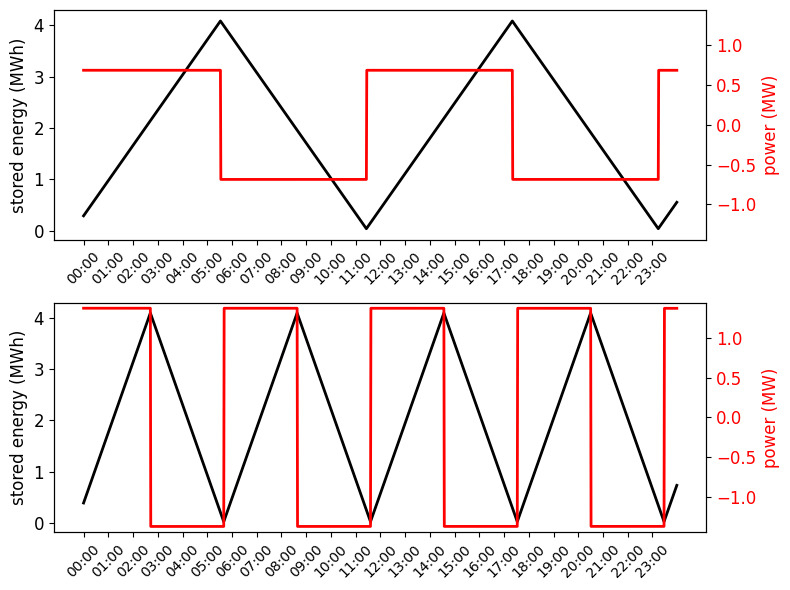

In [4]:
output_dir = "./figures"
os.makedirs(output_dir, exist_ok=True)
file_name = 'charging_profiles.pdf'
file_path = os.path.join(output_dir, file_name)
H = cell_constants['H']
times = pd.date_range(start=f'{2000}-01-01 00:00', end=f'{2000}-01-01 23:59', freq='1min')
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharey='col')

axes[0].plot(times, q_actual_1[H:2*H], label=r'$q_t$', color = 'black', linewidth = 2)
axes[0].set_ylabel('stored energy (MWh)', fontsize = 12)
axes[0].tick_params(axis = 'y', which = 'major', labelsize = 12, labelcolor='black')
axes[0].grid(False)
axes[0].set_xticks(pd.date_range(start=times.min(), end=times.max(), freq='h'))
axes[0].xaxis.set_major_formatter(DateFormatter('%H:%M'))
axes[0].tick_params(axis='x', rotation=45)
ax2 = axes[0].twinx()
ax2.plot(times, b_actual_1[H:2*H], label=r'$b_t$', color='red', linewidth=2)
ax2.set_ylabel('power (MW)', color='red', fontsize=12)
ax2.set_ylim(-4.125*0.35, 4.125*0.35)
ax2.tick_params(axis='y', labelcolor='red', labelsize=12)

axes[1].plot(times, q_actual_2[H:2*H], label=r'$q_t$', color = 'black', linewidth = 2)
axes[1].set_ylabel('stored energy (MWh)', fontsize = 12)
axes[1].tick_params(axis = 'y', which = 'major', labelsize = 12, labelcolor='black')
axes[1].grid(False)
axes[1].set_xticks(pd.date_range(start=times.min(), end=times.max(), freq='h'))
axes[1].xaxis.set_major_formatter(DateFormatter('%H:%M'))
axes[1].tick_params(axis='x', rotation=45)
ax4 = axes[1].twinx()
ax4.plot(times, b_actual_2[H:2*H], label=r'$b_t$', color='red', linewidth=2)
ax4.set_ylabel('power (MW)', color='red', fontsize=12)
ax4.set_ylim(-4.125*0.35, 4.125*0.35)
ax4.tick_params(axis='y', labelcolor='red', labelsize=12)
plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()

In [5]:
times_actual_1 = pd.date_range(start=f'{2025}-01-01 00:00', periods = E_sim_actual_1, freq='1min')
times_approx_1 = pd.date_range(start=f'{2025}-01-01 00:00', periods = E_sim_approx_1, freq='1min')
times_actual_2 = pd.date_range(start=f'{2025}-01-01 00:00', periods = E_sim_actual_2, freq='1min')
times_approx_2 = pd.date_range(start=f'{2025}-01-01 00:00', periods = E_sim_approx_2, freq='1min')

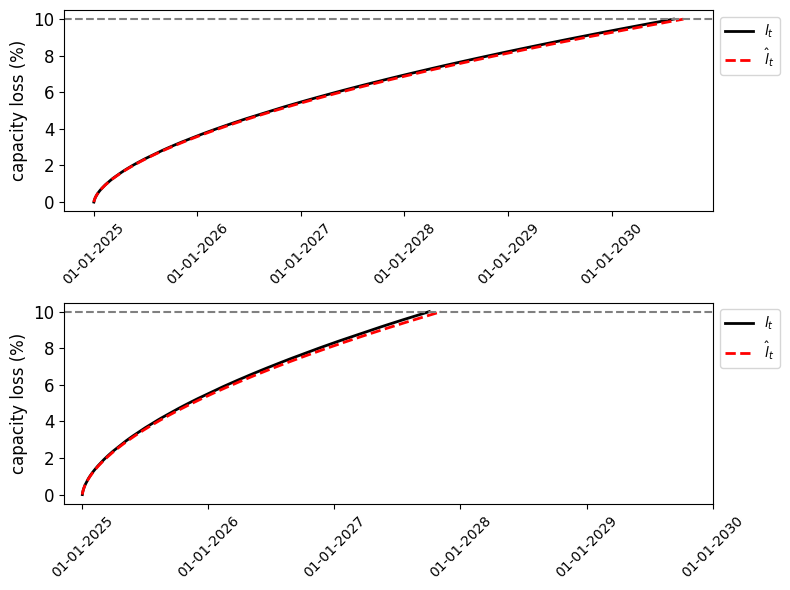

In [6]:
output_dir = "./figures"
os.makedirs(output_dir, exist_ok=True)
file_name = 'loss_profiles.pdf'
file_path = os.path.join(output_dir, file_name)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharey='col')

axes[0].plot(times_actual_1, l_actual_1*100, label=r'$l_t$', color = 'black', linewidth = 2, linestyle = 'solid')
axes[0].plot(times_approx_1, l_approx_1*100, label=r'$\hat{l}_t$', color = 'red', linewidth = 2, linestyle = 'dashed')
axes[0].axhline(y=np.max(l_actual_1*100), color='gray', linestyle='--', label='')
axes[0].set_ylabel('capacity loss (%)', fontsize=12)
axes[0].tick_params(axis='y', which='major', labelsize=12, labelcolor='black')
axes[0].grid(False)
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[0].set_xticks(pd.date_range(start=times_approx_1.min(), end=times_approx_1.max(), freq='YS'))
axes[0].xaxis.set_major_formatter(DateFormatter('%m-%d-%Y'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(times_actual_2, l_actual_2*100, label=r'$l_t$', color='black', linewidth=2, linestyle='solid')
axes[1].plot(times_approx_2, l_approx_2*100, label=r'$\hat{l}_t$', color='red', linewidth=2, linestyle='dashed')
axes[1].axhline(y=np.max(l_actual_2*100), color='gray', linestyle='--', label='')
axes[1].set_ylabel('capacity loss (%)', fontsize=12)
axes[1].tick_params(axis='y', which='major', labelsize=12, labelcolor='black')
axes[1].grid(False)
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].set_xticks(pd.date_range(start=times_approx_1.min(), end=times_approx_1.max(), freq='YS'))
axes[1].xaxis.set_major_formatter(DateFormatter('%m-%d-%Y'))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()

In [7]:
results_dir = './results'
os.makedirs(results_dir, exist_ok=True)
summary = pd.DataFrame([
    {'scenario': 'low_c_rate', 'model': 'detailed', 'C_max_per_hour': 0.333 / 2, 'lifetime_years': lifetime_actual_1, 'cycles': num_cycles_actual_1, 'ampere_hours_at_end': ah_at_the_end_actual_1},
    {'scenario': 'low_c_rate', 'model': 'approximation', 'C_max_per_hour': 0.333 / 2, 'lifetime_years': lifetime_approx_1, 'cycles': num_cycles_approx_1, 'ampere_hours_at_end': ah_at_the_end_approx_1},
    {'scenario': 'high_c_rate', 'model': 'detailed', 'C_max_per_hour': 0.333, 'lifetime_years': lifetime_actual_2, 'cycles': num_cycles_actual_2, 'ampere_hours_at_end': ah_at_the_end_actual_2},
    {'scenario': 'high_c_rate', 'model': 'approximation', 'C_max_per_hour': 0.333, 'lifetime_years': lifetime_approx_2, 'cycles': num_cycles_approx_2, 'ampere_hours_at_end': ah_at_the_end_approx_2},
])
summary_path = os.path.join(results_dir, 'aging_summary.csv')
summary.to_csv(summary_path, index=False)
print(summary.to_string(index=False))
print(f'Saved: {summary_path}')

   scenario         model  C_max_per_hour  lifetime_years  cycles  ampere_hours_at_end
 low_c_rate      detailed          0.1665        5.598925    4154         19131.716785
 low_c_rate approximation          0.1665        5.694787    4225         19459.191566
high_c_rate      detailed          0.3330        2.752315    4073         18809.578074
high_c_rate approximation          0.3330        2.847411    4213         19459.311630
Saved: ./results/aging_summary.csv
